# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import (f1_score,
                             accuracy_score,
                             recall_score,
                             precision_score,
                             classification_report,
                             confusion_matrix)

print("Everything Imported Boss✅")


Everything Imported Boss✅


# **Data Exploration**

## *Load The Data*

In [2]:
File_path = input("Enter the File Path: ").replace("\\",'\\')
df = pd.read_csv(File_path)

print("Data Loaded")

Data Loaded


## *Exploration*

In [3]:
print(f"The Dataset have {df.shape[0]} rows and {df.shape[1]} columns")

The Dataset have 694 rows and 8 columns


In [4]:
df.head()

,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
0,23.0,61.0,2303.0,1.0,67.6,13.8,79.0,0
1,20.0,75.0,338.0,2.0,71.5,1.4,89.0,1
2,20.0,167.0,1257.0,0.0,62.1,7.5,13.0,0
3,11.0,87.0,1274.0,2.0,12.4,9.1,64.0,0
4,5.0,56.0,2567.0,2.0,73.7,7.5,19.0,0


In [5]:
df.tail()

,departure_hour,scheduled_duration_min,distance_miles,num_connections,wind_speed_kmh,visibility_km,prev_flight_delay_min,is_delayed
689,8.0,180.0,1668.0,1.0,25.4,1.6,31.0,0
690,21.0,126.0,1832.0,0.0,79.7,1.0,47.0,1
691,19.0,314.0,2613.0,1.0,3.7,10.8,35.0,1
692,2.0,181.0,2881.0,2.0,17.9,5.7,21.0,1
693,4.0,143.0,1220.0,1.0,22.8,4.6,23.0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   departure_hour          694 non-null    float64
 1   scheduled_duration_min  694 non-null    float64
 2   distance_miles          694 non-null    float64
 3   num_connections         694 non-null    float64
 4   wind_speed_kmh          673 non-null    str    
 5   visibility_km           674 non-null    float64
 6   prev_flight_delay_min   694 non-null    float64
 7   is_delayed              694 non-null    int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 46.2 KB


In [7]:
df.describe()

,departure_hour,scheduled_duration_min,distance_miles,num_connections,visibility_km,prev_flight_delay_min,is_delayed
count,694.000000,694.000000,694.000000,694.000000,674.000000,694.000000,694.000000
mean,11.306916,204.734870,1549.951009,0.976945,8.013353,42.469741,0.491354
std,7.095883,89.881911,849.515292,0.828454,4.008802,26.394249,0.500286
min,0.000000,45.000000,0.000000,0.000000,-3.000000,-50.000000,0.000000
25%,5.000000,126.500000,778.000000,0.000000,4.600000,19.000000,0.000000
50%,11.000000,209.000000,1538.500000,1.000000,8.100000,42.000000,0.000000
75%,18.000000,281.000000,2303.000000,2.000000,11.400000,64.000000,1.000000
max,28.000000,359.000000,2999.000000,2.000000,15.000000,89.000000,1.000000


In [8]:
print(f'The Dataset have {df.duplicated().sum()} Duplicates')

The Dataset have 14 Duplicates


In [9]:
print('The Dataset have following Nan values: ')
df.isna().sum()

The Dataset have following Nan values: 


departure_hour             0
scheduled_duration_min     0
distance_miles             0
num_connections            0
wind_speed_kmh            21
visibility_km             20
prev_flight_delay_min      0
is_delayed                 0
dtype: int64

# **Data Cleaning**

**Create Copy**

In [10]:
df_copy = df.copy()
print('Copy created boss')

Copy created boss


**Data Type correction**

In [11]:
df_copy['wind_speed_kmh'] = df_copy['wind_speed_kmh'].replace('_err','',regex=True)
df_copy['wind_speed_kmh'] = df_copy['wind_speed_kmh'].astype('float')

**Outliers**

In [12]:
columns = df_copy.select_dtypes(include='number').columns.tolist()

# remove target column properly
columns.remove('is_delayed')

for col in columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


**Duplicates**

In [13]:
print(f'before removing the dataset have {df_copy.duplicated().sum()} duplicates and after cleaning the dataset have {df_copy.drop_duplicates(inplace=True)}')

before removing the dataset have 14 duplicates and after cleaning the dataset have None


**NaN Values**

In [14]:
print("The Columns have Following NaN values: ")
print(df_copy.isna().sum())
df_copy.dropna(inplace=True)
print("\nThe Columns have Following NaN values After Cleaning: ")
print(df_copy.isna().sum())

The Columns have Following NaN values: 
departure_hour             0
scheduled_duration_min     0
distance_miles             0
num_connections            0
wind_speed_kmh            21
visibility_km             20
prev_flight_delay_min      1
is_delayed                 0
dtype: int64

The Columns have Following NaN values After Cleaning: 
departure_hour            0
scheduled_duration_min    0
distance_miles            0
num_connections           0
wind_speed_kmh            0
visibility_km             0
prev_flight_delay_min     0
is_delayed                0
dtype: int64


**Check**

In [15]:
print(f"The dataset have {df_copy.shape[0]} rows after cleaning and {df_copy.shape[1]} columns")

The dataset have 638 rows after cleaning and 8 columns


# **Data Preperation**

**Feature and target column**

In [16]:
X = df_copy[['departure_hour',
             'scheduled_duration_min',
             'distance_miles',
             'num_connections',
             'wind_speed_kmh',
             'visibility_km',
             'prev_flight_delay_min']]

y = df_copy['is_delayed']

print(f"X shape: {X.shape}")
print(f'y Shape: {y.shape}')

X shape: (638, 7)
y Shape: (638,)


**Test & Train split**

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=42)


print(f"X_train shape: {X_train.shape}")
print(f'y_train Shape: {y_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'y_test Shape: {y_test.shape}')

X_train shape: (510, 7)
y_train Shape: (510,)
X_test Shape: (128, 7)
y_test Shape: (128,)


# **Model**

**Train**

In [18]:
model = DecisionTreeClassifier(max_depth=3,
                               min_samples_leaf=5,
                               min_samples_split=10,
                               random_state=42)

model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


**Test**

In [19]:
# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.63      0.64        67
           1       0.60      0.62      0.61        61

    accuracy                           0.62       128
   macro avg       0.62      0.62      0.62       128
weighted avg       0.63      0.62      0.63       128

[[42 25]
 [23 38]]


                  Feature  Importance
4          wind_speed_kmh      0.3321
5           visibility_km      0.2655
3         num_connections      0.1771
2          distance_miles      0.1203
6   prev_flight_delay_min      0.1050
1  scheduled_duration_min      0.0000
0          departure_hour      0.0000


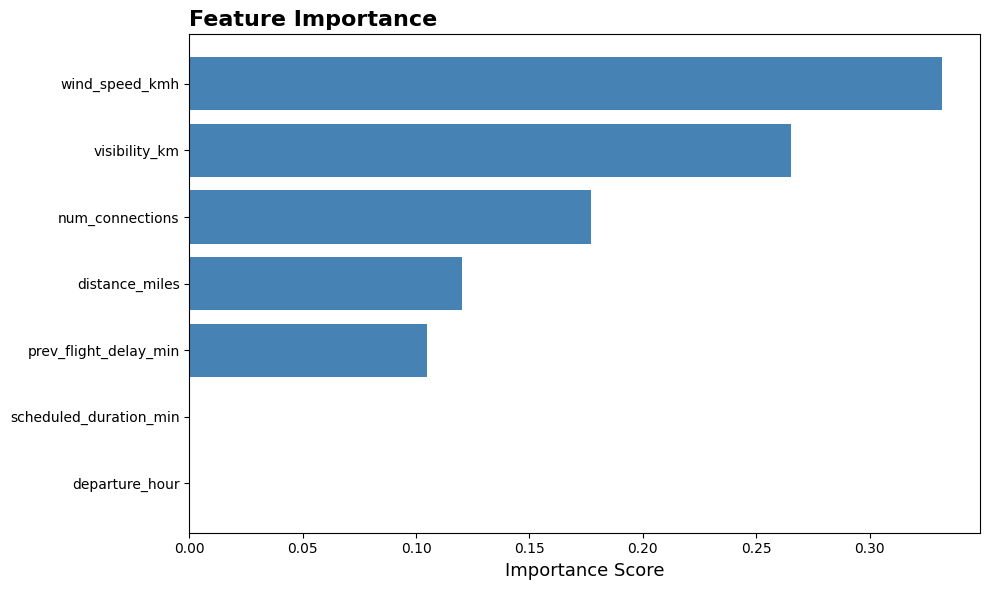

In [20]:
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_.round(4)
}).sort_values('Importance', ascending=False)

print(importance_df)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], 
         importance_df['Importance'], 
         color='steelblue')
plt.xlabel('Importance Score', fontsize=13)
plt.title('Feature Importance', fontsize=16, 
          fontweight='bold', loc='left')
ax = plt.gca()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

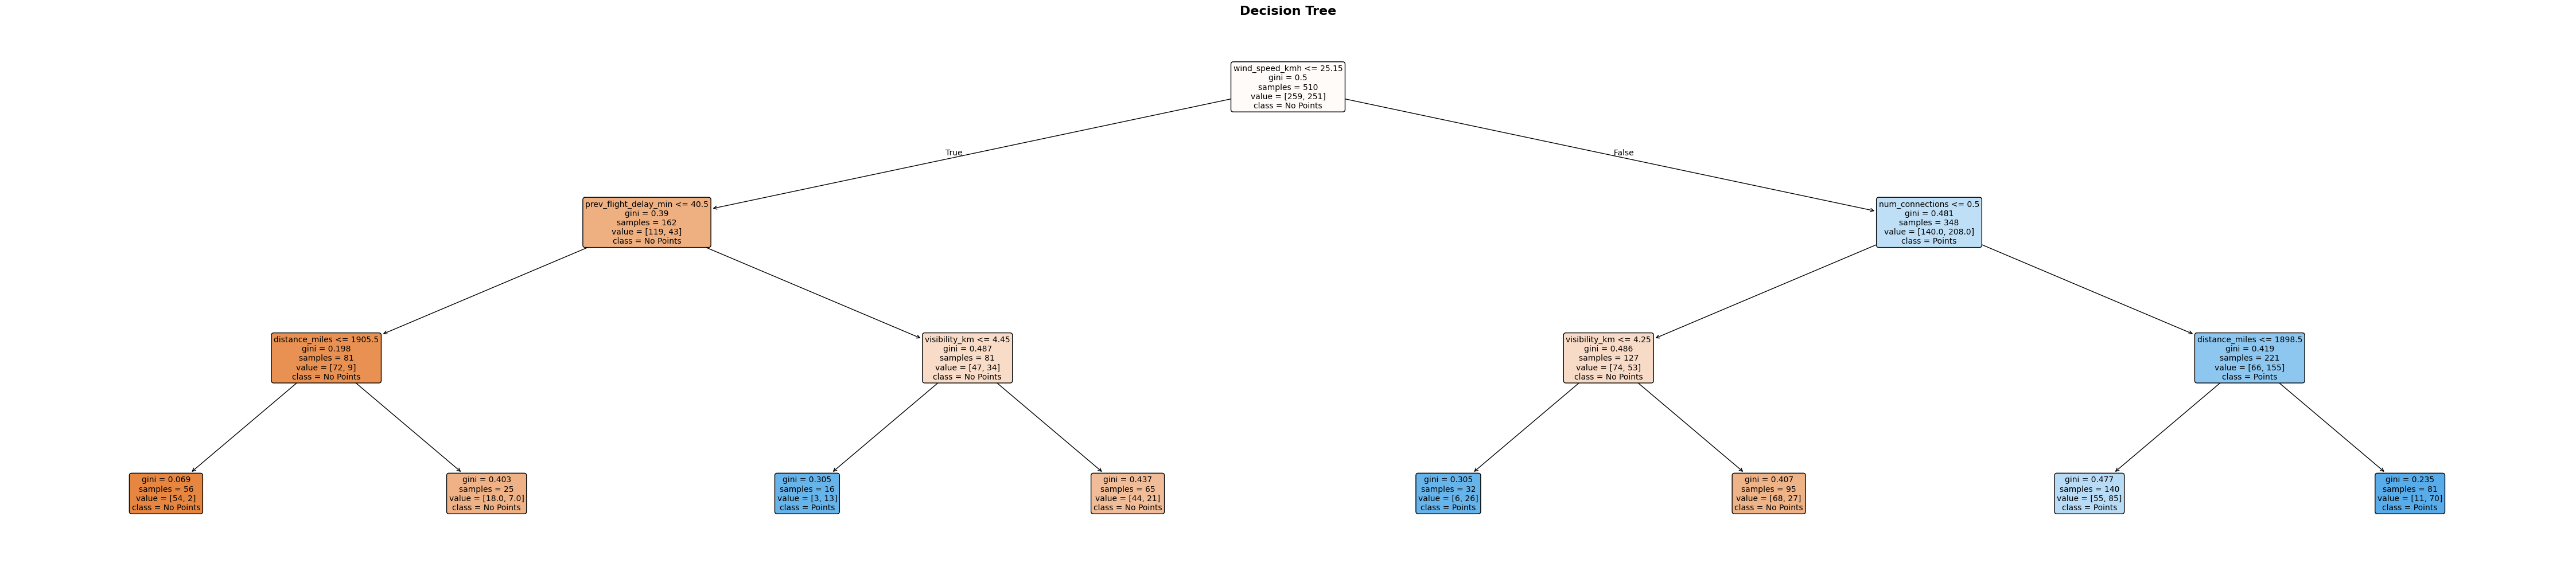

In [21]:
plt.figure(figsize=(45, 10))

plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=['No Points', 'Points'],
    filled=True,          # colour nodes by class
    rounded=True,         # rounded boxes
    fontsize=10
)

plt.title('Decision Tree', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.7412
Testing Accuracy:  0.6250
Gap:               0.1162


# **Chart**

**All in One**

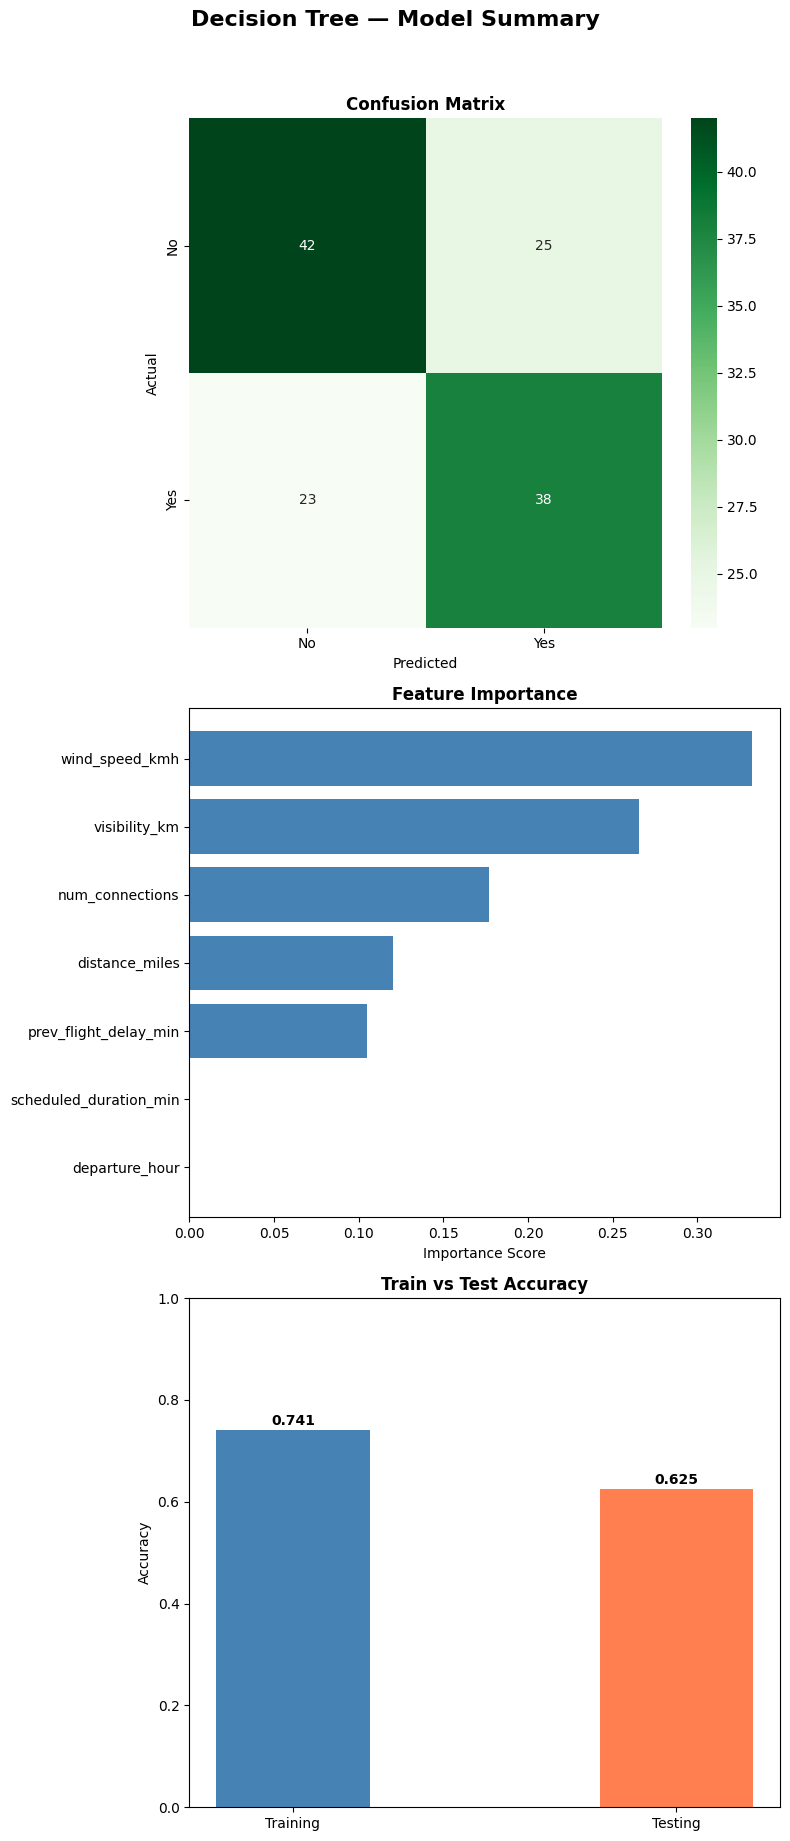

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(8, 18))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 2: Feature Importance ---
importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance')

axes[1].barh(importance_df['Feature'],
             importance_df['Importance'],
             color='steelblue')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# --- Plot 3: Train vs Test Accuracy ---
labels  = ['Training', 'Testing']
scores  = [train_acc, test_acc]
colors  = ['steelblue', 'coral']

axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', 
                 ha='center', fontweight='bold')

plt.suptitle('Decision Tree — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()